# Temporal Demand & Revenue Aggregation
**Core Pattern:** GroupBy & Hashing Aggregations

Hourly trip volume and revenue.

In [1]:
import sys, os

try:
    import datapunk  # noqa: F401
except ImportError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

os.environ["DAFT_PROGRESS_BAR"] = "0"
import plotly.io as pio

pio.renderers.default = "svg"

from datapunk.reporter import DatapunkReporter

RAM_CAP = 1024  # in MB

reporter = DatapunkReporter(
    small_months=1,
    large_cap_mb=RAM_CAP,
    with_lookup=False,
)

  ⚙ unifying schema across 24 files (20 cols)…
     ✅ unified files cached.


Datapunk Environment
----------------------------------------------------
  OS:        Darwin 25.3.0
  CPU:       Apple M1 Pro (8 cores)
  RAM:       16.0 GB
  Python:    v3.14.6
  Small run: 1 month, uncapped, 10 iter + 1 warmup
  Large run: 24 months, cap = 1024 MB (physical RSS), 1 iter + 0 warmup
----------------------------------------------------


## Analytics Functions

In [2]:
# Hourly trip volume and revenue. Each engine returns its native materialized
# result; verification and chart conversion happen after timing.
TAXI_COLS = ["tpep_pickup_datetime", "total_amount"]


def _duckdb_materialize(query, params, *, capped=False):
    import duckdb
    import uuid
    from datapunk.fingerprint import DuckDBTableResult

    con = duckdb.connect()
    if capped:
        con.execute(f"SET memory_limit='{int(RAM_CAP * 0.8)}MB'")

    table = f"datapunk_result_{uuid.uuid4().hex}"
    con.execute(f"CREATE TEMP TABLE {table} AS {query}", params)
    return DuckDBTableResult(con=con, table=table)


def temporal_demand_pandas(file_path):
    import pandas as pd

    df = pd.concat(
        [pd.read_parquet(p, columns=TAXI_COLS) for p in file_path],
        ignore_index=True,
    )
    df = df.dropna(subset=["tpep_pickup_datetime"])
    df = df.assign(pickup_hour=df["tpep_pickup_datetime"].dt.hour)
    result = (
        df.groupby("pickup_hour", sort=True)
        .agg(
            total_trips=("total_amount", "size"), total_revenue=("total_amount", "sum")
        )
        .reset_index()
        .copy()
    )
    return result, {"engine": pd.__name__, "version": pd.__version__}


def temporal_demand_polars(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .select(
            [
                pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
                pl.col("total_amount"),
            ]
        )
        .drop_nulls(["pickup_hour"])
        .group_by("pickup_hour")
        .agg(
            [
                pl.len().alias("total_trips"),
                pl.col("total_amount").sum().alias("total_revenue"),
            ]
        )
    )
    result = lf.collect()
    return result, {"engine": pl.__name__, "version": pl.__version__}


def temporal_demand_polars_streaming(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .select(
            [
                pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
                pl.col("total_amount"),
            ]
        )
        .drop_nulls(["pickup_hour"])
        .group_by("pickup_hour")
        .agg(
            [
                pl.len().alias("total_trips"),
                pl.col("total_amount").sum().alias("total_revenue"),
            ]
        )
    )
    result = lf.collect(engine="streaming")
    return result, {"engine": f"{pl.__name__}-streaming", "version": pl.__version__}


def temporal_demand_duckdb(file_path):
    import duckdb

    query = """
        SELECT
            EXTRACT(HOUR FROM tpep_pickup_datetime)::INTEGER AS pickup_hour,
            COUNT(*) AS total_trips,
            SUM(total_amount) AS total_revenue
        FROM read_parquet($files)
        WHERE tpep_pickup_datetime IS NOT NULL
        GROUP BY 1
    """
    result = _duckdb_materialize(query, {"files": list(map(str, file_path))})
    return result, {"engine": duckdb.__name__, "version": duckdb.__version__}


def temporal_demand_duckdb_capped(file_path):
    import duckdb

    query = """
        SELECT
            EXTRACT(HOUR FROM tpep_pickup_datetime)::INTEGER AS pickup_hour,
            COUNT(*) AS total_trips,
            SUM(total_amount) AS total_revenue
        FROM read_parquet($files)
        WHERE tpep_pickup_datetime IS NOT NULL
        GROUP BY 1
    """
    result = _duckdb_materialize(
        query, {"files": list(map(str, file_path))}, capped=True
    )
    return result, {
        "engine": f"{duckdb.__name__}-capped",
        "version": duckdb.__version__,
    }


def temporal_demand_dask(file_path):
    import dask
    import dask.dataframe as dd

    df = dd.read_parquet(file_path, columns=TAXI_COLS)
    df = df.dropna(subset=["tpep_pickup_datetime"])
    df = df.assign(pickup_hour=df["tpep_pickup_datetime"].dt.hour)
    result = (
        df.groupby("pickup_hour")
        .agg(
            total_trips=("total_amount", "size"), total_revenue=("total_amount", "sum")
        )
        .reset_index()
        .compute()
    )
    return result, {"engine": dask.__name__, "version": dask.__version__}


def temporal_demand_daft(file_path):
    import daft
    from daft import col
    import daft.functions as F

    df = daft.read_parquet(list(file_path)).select(
        "tpep_pickup_datetime", "total_amount"
    )
    df = df.filter(F.not_null(col("tpep_pickup_datetime")))
    df = df.with_column("pickup_hour", F.hour(col("tpep_pickup_datetime")))
    result = (
        df.groupby("pickup_hour")
        .agg(
            [
                daft.lit(1).count().alias("total_trips"),
                col("total_amount").sum().alias("total_revenue"),
            ]
        )
        .collect()
    )
    return result, {"engine": daft.__name__, "version": daft.__version__}


ANALYTICS = [
    temporal_demand_pandas,
    temporal_demand_polars,
    temporal_demand_polars_streaming,
    temporal_demand_duckdb,
    temporal_demand_duckdb_capped,
    temporal_demand_dask,
    temporal_demand_daft,
]

## Execution & Verification

In [3]:
reporter.run_all(ANALYTICS, target_cols=["pickup_hour", "total_trips", "total_revenue"])
reporter.export_results(
    suite_id="02",
    title="Temporal Demand & Revenue Aggregation",
    core_pattern="GroupBy & Hashing Aggregations",
    description="Hourly trip volume and revenue across 24 months.",
)


▶ SMALL run (1 month, cap=none)


    pandas v3.0.3              107 ms  peak 374 MB


    polars v1.41.2              30 ms  peak 289 MB


    polars-streaming v1.41.2      23 ms  peak 269 MB


    duckdb v1.5.4               37 ms  peak 149 MB


...

    polars-streaming v1.41.2     513 ms  peak 563 MB


    duckdb v1.5.4              631 ms  peak 213 MB


    duckdb-capped v1.5.4       631 ms  peak 213 MB


    dask v2026.6.0                OOM  peak 1070 MB


    daft v0.7.15               793 ms  peak 490 MB
    → consistency: ✅ 4 engine(s) agree (24 rows)
📊 exported suite [02] → docs/benchmark_results.json


## Analysis

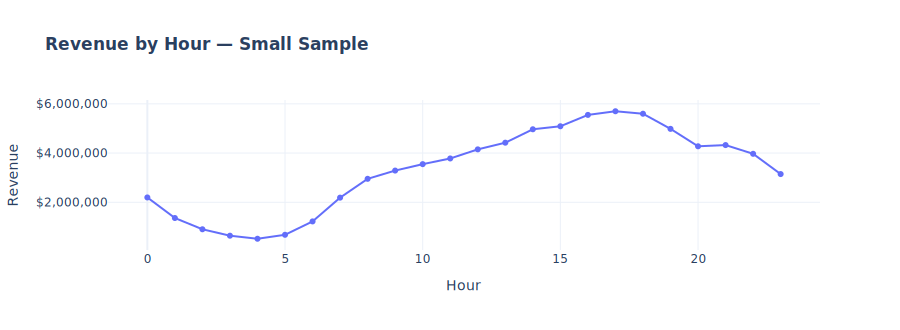

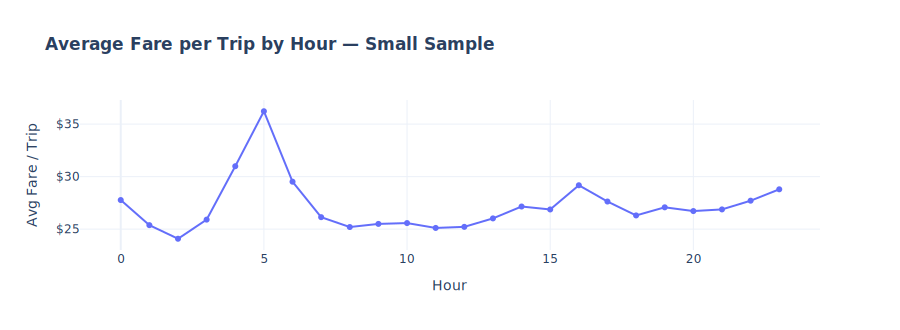

In [4]:
import plotly.express as px

# Visualization is intentionally standardized through pandas on the small run.
reporter.set_analysis_fn(temporal_demand_pandas, mode="small")
df = reporter.get_analysis_df(
    ["pickup_hour", "total_trips", "total_revenue"]
).sort_values("pickup_hour")
df["avg_fare"] = df["total_revenue"] / df["total_trips"]
fig = px.line(
    df,
    x="pickup_hour",
    y="total_revenue",
    markers=True,
    title="<b>Revenue by Hour — Small Sample</b>",
    labels={"pickup_hour": "Hour", "total_revenue": "Revenue"},
)
fig.update_layout(template="plotly_white", yaxis_tickformat="$,", width=900, height=330)
fig.show()
fig2 = px.line(
    df,
    x="pickup_hour",
    y="avg_fare",
    markers=True,
    title="<b>Average Fare per Trip by Hour — Small Sample</b>",
    labels={"pickup_hour": "Hour", "avg_fare": "Avg Fare / Trip"},
)
fig2.update_layout(
    template="plotly_white", yaxis_tickformat="$,", width=900, height=330
)
fig2.show()

## Performance Comparison

In [5]:
reporter.show_scorecard("Temporal Demand Aggregation")

#### Temporal Demand Aggregation — Single Month · Uncapped

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | 0.1075s | 1.3×       | 374 MB     | —        |
| daft v0.7.15             | 0.0512s | 2.8×       | 170 MB     | —        |
| dask v2026.6.0           | 0.1410s | 1.0×       | 397 MB     | —        |
| duckdb v1.5.4            | 0.0370s | 3.8×       | 149 MB     | —        |
| duckdb-capped v1.5.4     | 0.0370s | 3.8×       | 151 MB     | —        |
| polars v1.41.2           | 0.0298s | 4.7×       | 289 MB     | —        |
| polars-streaming v1.41.2 | 0.0231s | **6.1×**   | 269 MB     | —        |

*✅ 7 engine(s) agree (24 rows)*

#### Temporal Demand Aggregation — Full Window · 1024 MB Cap

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | **OOM** | —          | ≥1038 MB   | ≥1.01    |
| daft v0.7.15             | 0.7930s | 1.0×       | 490 MB     | 0.48     |
| dask v2026.6.0           | **OOM** | —          | ≥1070 MB   | ≥1.05    |
| duckdb v1.5.4            | 0.6309s | 1.3×       | 213 MB     | 0.21     |
| duckdb-capped v1.5.4     | 0.6310s | 1.3×       | 213 MB     | 0.21     |
| polars v1.41.2           | **OOM** | —          | ≥1143 MB   | ≥1.12    |
| polars-streaming v1.41.2 | 0.5130s | **1.5×**   | 563 MB     | 0.55     |

*✅ 4 engine(s) agree (24 rows)*